In [4]:
# 1. Define the path to your zip file (I fixed the syntax for you)
zip_path = "/content/drive/MyDrive/Hate_speech_task_AI/4. Hate Speech Detection Dataset-20260507T053146Z-3-001.zip"

# 2. Unzip it into a folder called 'hate_data'
!unzip -q "{zip_path}" -d "/content/hate_data"

# 3. See what is inside the folder
import os
print("Files in the folder:", os.listdir("/content/hate_data"))

Files in the folder: ['4. Hate Speech Detection Dataset']


In [5]:
import os

# This will search the folder and show us every file inside it
print("Searching for CSV files...")
for root, dirs, files in os.walk('/content/hate_data'):
    for file in files:
        if file.endswith(".csv"):
            print(f"FOUND IT: {os.path.join(root, file)}")

Searching for CSV files...
FOUND IT: /content/hate_data/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv


In [6]:
import pandas as pd

# 1. PASTE the path you found in Step 1 here
real_csv_path = "/content/hate_data/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv"

# 2. Load the data
df = pd.read_csv(real_csv_path)

# 3. Show the first 5 rows and the column names
print("✅ Dataset Loaded Successfully!")
print(df.columns) # This tells us if the column is named 'tweet' or 'text'
print(df.head())

✅ Dataset Loaded Successfully!
Index(['label', 'text'], dtype='object')
                label                                               text
0             neither  !!! RT @mayasolovely: As a woman you shouldn't...
1  offensive language  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2  offensive language  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3  offensive language  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4  offensive language  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Clean the Text  and Encode Labels (The Preprocessing)

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
nltk.download('stopwords')

# 1. Fix the cleaning function
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'RT', '', text) # Remove 'RT' (Retweet) tags
    text = re.sub(r'@[\w]*', '', text) # Remove @mentions
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-zA-Z]', ' ', text) # Remove special characters
    text = text.lower()
    stop_words = set(stopwords.words('english'))
    words = text.split()
    clean_words = [w for w in words if w not in stop_words]
    return " ".join(clean_words)

# 2. Apply cleaning to the 'text' column (Fixed the name here)
print("Cleaning text... please wait.")
df['clean_text'] = df['text'].apply(clean_tweet)

# 3. Convert labels (neither, offensive language, hate speech) into numbers
# This is required for the Deep Learning model
le = LabelEncoder()
df['label_num'] = le.fit_transform(df['label'])

print("\n✅ Text Cleaned and Labels Encoded!")
print(df[['text', 'clean_text', 'label', 'label_num']].head())

# Show the mapping so you know which number is which
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabel Mapping:", mapping)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning text... please wait.

✅ Text Cleaned and Labels Encoded!
                                                text  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   

                                          clean_text               label  \
0  woman complain cleaning house amp man always t...             neither   
1  boy dats cold tyga dwn bad cuffin dat hoe st p...  offensive language   
2       dawg ever fuck bitch start cry confused shit  offensive language   
3                                   look like tranny  offensive language   
4     shit hear might true might faker bitch told ya  offensive language   

   label_num  
0          1  
1          2  
2          2  
3          2  
4          2  

Label Mapping: {'hate speec': np.int64(0), 'neith

Class Distribution Plot

/tmp/ipykernel_6184/3576197753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette=['#e74c3c', '#3498db', '#2ecc71'])


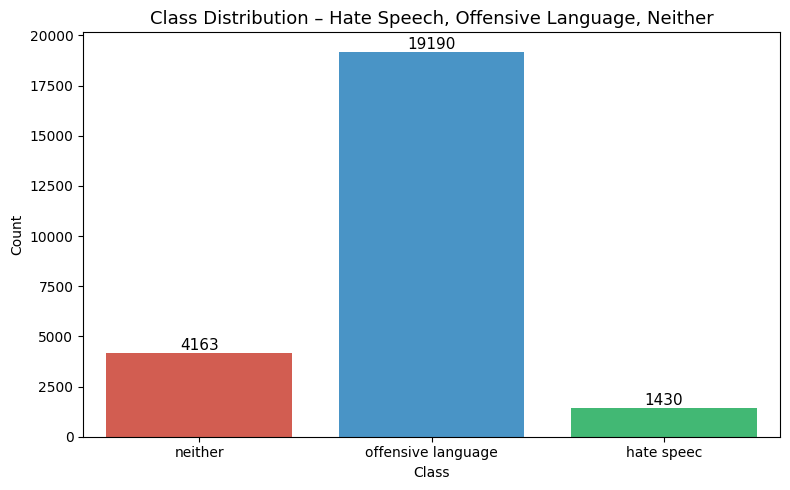

In [14]:
# --- CLASS DISTRIBUTION PLOT (Screenshot 1) ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Class Distribution – Hate Speech, Offensive Language, Neither', fontsize=13)
plt.xlabel('Class')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

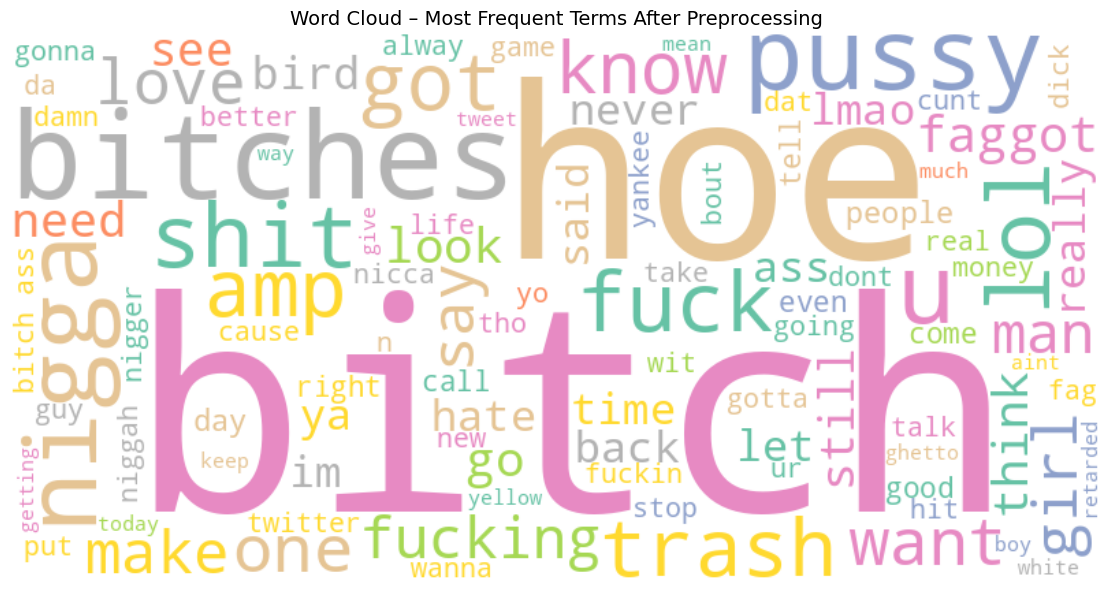

In [15]:
# --- WORD CLOUD (Screenshot 2) ---
from wordcloud import WordCloud

all_text = " ".join(df['clean_text'].dropna())

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='Set2'
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – Most Frequent Terms After Preprocessing', fontsize=14)
plt.tight_layout()
plt.show()

Train the Word2Vec Model

In [9]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.4 MB/s eta 0:00:00


In [17]:
from gensim.models import Word2Vec
import numpy as np

# 1. Tokenize the cleaned text
tokenized_text = df['clean_text'].apply(lambda x: x.split())

# 2. Train the Word2Vec model
print("Training Word2Vec model...")
# vector_size=100 means each word becomes a list of 100 numbers
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=1, workers=4)

# 3. Test it
word = "woman"
if word in w2v_model.wv:
    print(f"Words similar to '{word}':", w2v_model.wv.most_similar(word))

# 4. Save it to your Drive
w2v_model.save("/content/drive/MyDrive/hate_speech_w2v.model")
print("✅ Word2Vec model saved successfully!")

Training Word2Vec model...
Words similar to 'woman': [('hair', 0.9997729659080505), ('long', 0.9997696876525879), ('took', 0.9997662901878357), ('live', 0.9997661709785461), ('b', 0.9997648000717163), ('guy', 0.9997630715370178), ('work', 0.9997614026069641), ('w', 0.9997606873512268), ('went', 0.9997599124908447), ('since', 0.9997494220733643)]
✅ Word2Vec model saved successfully!


Prepare the Sequences

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Initialize the Tokenizer
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(df['clean_text'])

# 2. Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# 3. Pad sequences so they all have the same length (50 words)
# This creates the 'X' variable you were missing
max_len = 50
X = pad_sequences(sequences, maxlen=max_len)

# 4. Get the labels
# This creates the 'y' variable you were missing
y = df['label_num'].values

print(f"✅ X and y are now defined!")
print(f"X shape: {X.shape} (This is your input data)")

✅ X and y are now defined!
X shape: (24783, 50) (This is your input data)


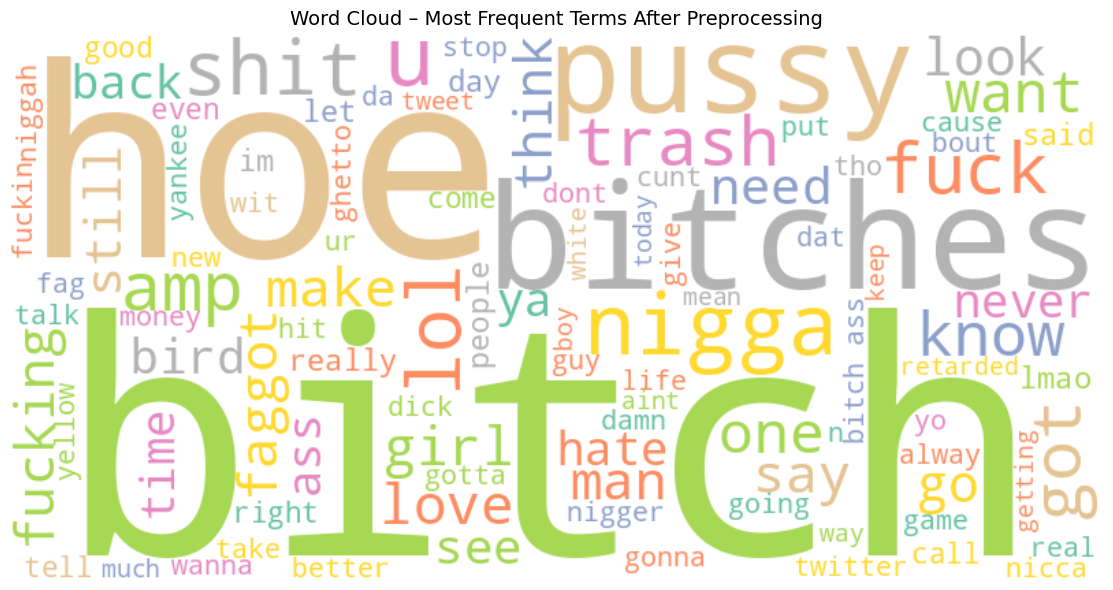

In [19]:

#re-using the  code
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all cleaned text into one string
all_text = " ".join(df['clean_text'].dropna())

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='Set2'
).generate(all_text)

# Display it
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – Most Frequent Terms After Preprocessing', fontsize=14)
plt.tight_layout()
plt.show()

Create the Embedding Matrix

In [33]:
# Create a matrix of weights for the Embedding layer
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index) + 1, 100))

for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

print("✅ Embedding Matrix Created!")

✅ Embedding Matrix Created!


Build and Train the LSTM Model

Save the Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

# Find your CSV
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Copy of mnist_3_and_5.csv
/content/drive/MyDrive/ConceptAI/Titanic-Dataset.csv
/content/drive/MyDrive/ConceptAI/bank.csv
/content/drive/MyDrive/ConceptAI/medical_students_dataset.csv
/content/drive/MyDrive/GRP9_BIGData/Global Wind Power Tracker (GWPT) Summary Data - December 2023 - New Wind Power Capacity by Country and Year.csv


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/Hate_speech_task_AI'):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/Hate_speech_task_AI/4. Hate Speech Detection Dataset-20260507T053146Z-3-001.zip


train/test split cell

In [26]:
from sklearn.model_selection import train_test_split

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Train size: {len(X_train)}, Test size: {len(X_test)}")

✅ Train size: 19826, Test size: 4957


Class Weights

In [27]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))
print("✅ Class Weights:", class_weights_dict)

✅ Class Weights: {0: np.float64(5.776806526806527), 1: np.float64(1.9845845845845846), 2: np.float64(0.4304759423310752)}


add Model 1 + Model 2

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D

vocab_size = len(tokenizer.word_index) + 1

# MODEL 1 - Simple RNN
model1 = Sequential([
    Embedding(vocab_size, 100, input_length=50),
    SpatialDropout1D(0.2),
    SimpleRNN(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("✅ Model 1 - Simple RNN ready!")

# MODEL 2 - LSTM trainable embedding
model2 = Sequential([
    Embedding(vocab_size, 100, input_length=50),
    SpatialDropout1D(0.2),
    LSTM(100, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("✅ Model 2 - LSTM ready!")

✅ Model 1 - Simple RNN ready!
✅ Model 2 - LSTM ready!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training

In [29]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'RT', '', text)
    text = re.sub(r'@[\w]*', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'#[\w]*', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_tweet)
print("✅ Text Cleaned!")
print(df[['text', 'clean_text']].head(3))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ Text Cleaned!
                                                text  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   

                                          clean_text  
0  woman complain cleaning house amp man always t...  
1  boy dat cold tyga dwn bad cuffin dat hoe st place  
2       dawg ever fuck bitch start cry confused shit  


In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train Model 1 - Simple RNN
print("="*50)
print("Training Model 1 - Simple RNN...")
print("="*50)
h1 = model1.fit(X_train, y_train, epochs=15, batch_size=64,
                validation_data=(X_test, y_test),
                class_weight=class_weights_dict,
                callbacks=[early_stop])

# Train Model 2 - LSTM
print("="*50)
print("Training Model 2 - LSTM...")
print("="*50)
h2 = model2.fit(X_train, y_train, epochs=15, batch_size=64,
                validation_data=(X_test, y_test),
                class_weight=class_weights_dict,
                callbacks=[early_stop])



# Train Model 3 - LSTM + Word2Vec
print("="*50)
print("Training Model 3 - LSTM + Word2Vec...")
print("="*50)
h3 = model3.fit(X_train, y_train, epochs=15, batch_size=64,
                validation_data=(X_test, y_test),
                class_weight=class_weights_dict,
                callbacks=[early_stop])

print("\n✅ All 3 models trained!")# Train Model 3 - LSTM + Word2Vec (model_balanced)
print("="*50)
print("Training Model 3 - LSTM + Word2Vec...")
print("="*50)
h3 = model_balanced.fit(X_train, y_train, epochs=15, batch_size=64,
                validation_data=(X_test, y_test),
                class_weight=class_weights_dict,
                callbacks=[early_stop])

print("\n✅ All 3 models trained!")

Training Model 1 - Simple RNN...
Epoch 1/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.7074 - loss: 0.7963 - val_accuracy: 0.8344 - val_loss: 0.5264
Epoch 2/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.8476 - loss: 0.4179 - val_accuracy: 0.7474 - val_loss: 0.6348
Epoch 3/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9014 - loss: 0.2229 - val_accuracy: 0.8338 - val_loss: 0.4464
Epoch 4/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9452 - loss: 0.1265 - val_accuracy: 0.8358 - val_loss: 0.4901
Epoch 5/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9583 - loss: 0.0941 - val_accuracy: 0.8461 - val_loss: 0.5099
Epoch 6/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9648 - loss: 0.0824 - val_accuracy: 0.8461 - val_loss: 0.5603
Training Model 2 - LSTM...
Epoch 1/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 57s 166ms/step - accuracy: 0.7257 - loss: 0.7544 - val_accuracy: 0.8451 - val_loss: 0.4810
Epoch 2/15
310/310 ━━━━━━━━━━

NameError: name 'model3' is not defined

In [34]:
# Rebuild Model 3 quickly
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = len(tokenizer.word_index) + 1

model3 = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=50,
              trainable=False),
    SpatialDropout1D(0.2),
    LSTM(100, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model3.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
print("✅ Model 3 rebuilt!")

# Train Model 3
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print("Training Model 3 - LSTM + Word2Vec...")
h3 = model3.fit(X_train, y_train, epochs=15, batch_size=64,
                validation_data=(X_test, y_test),
                class_weight=class_weights_dict,
                callbacks=[early_stop])
print("✅ Model 3 trained!")

✅ Model 3 rebuilt!
Training Model 3 - LSTM + Word2Vec...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.5728 - loss: 1.0243 - val_accuracy: 0.6938 - val_loss: 0.9268
Epoch 2/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.6507 - loss: 0.9555 - val_accuracy: 0.8017 - val_loss: 0.8293
Epoch 3/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 32s 104ms/step - accuracy: 0.6536 - loss: 0.9344 - val_accuracy: 0.7351 - val_loss: 0.8501
Epoch 4/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.7031 - loss: 0.9226 - val_accuracy: 0.7866 - val_loss: 0.8331
Epoch 5/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.6997 - loss: 0.9095 - val_accuracy: 0.7436 - val_loss: 0.8520
✅ Model 3 trained!


Save all 3 models

In [36]:
# Save all 3 models
model1.save('/content/drive/MyDrive/nlp_model1_rnn.keras')
print("✅ Model 1 saved!")

model2.save('/content/drive/MyDrive/nlp_model2_lstm.keras')
print("✅ Model 2 saved!")

model3.save('/content/drive/MyDrive/nlp_model3_lstm_w2v.keras')
print("✅ Model 3 saved!")

# Save histories too
import pickle
with open('/content/drive/MyDrive/nlp_histories.pkl', 'wb') as f:
    pickle.dump({'h1': h1.history, 'h2': h2.history, 'h3': h3.history}, f)
print("✅ Training histories saved!")

✅ Model 1 saved!
✅ Model 2 saved!
✅ Model 3 saved!
✅ Training histories saved!


Model Summaries

In [35]:
# After model1 is defined
print("="*50)
print("MODEL 1 – Simple RNN Summary")
print("="*50)
model1.summary()

MODEL 1 – Simple RNN Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 100)        │     1,987,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,999,819 (22.89 MB)

 Trainable params: 1,999,939 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,999,880 (15.26 MB)

In [37]:
# After model2 is defined
print("="*50)
print("MODEL 2 – LSTM Summary")
print("="*50)
model2.summary()

MODEL 2 – LSTM Summary


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 100)        │     1,987,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,222,779 (23.74 MB)

 Trainable params: 2,074,259 (7.91 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,148,520 (15.83 MB)

In [38]:
# After model3 is defined
print("="*50)
print("MODEL 3 – LSTM + Word2Vec Summary")
print("="*50)
model3.summary()

MODEL 3 – LSTM + Word2Vec Summary


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 100)        │     1,987,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,248,379 (8.58 MB)

 Trainable params: 87,059 (340.07 KB)

 Non-trainable params: 1,987,200 (7.58 MB)

 Optimizer params: 174,120 (680.16 KB)

Comparison Plots

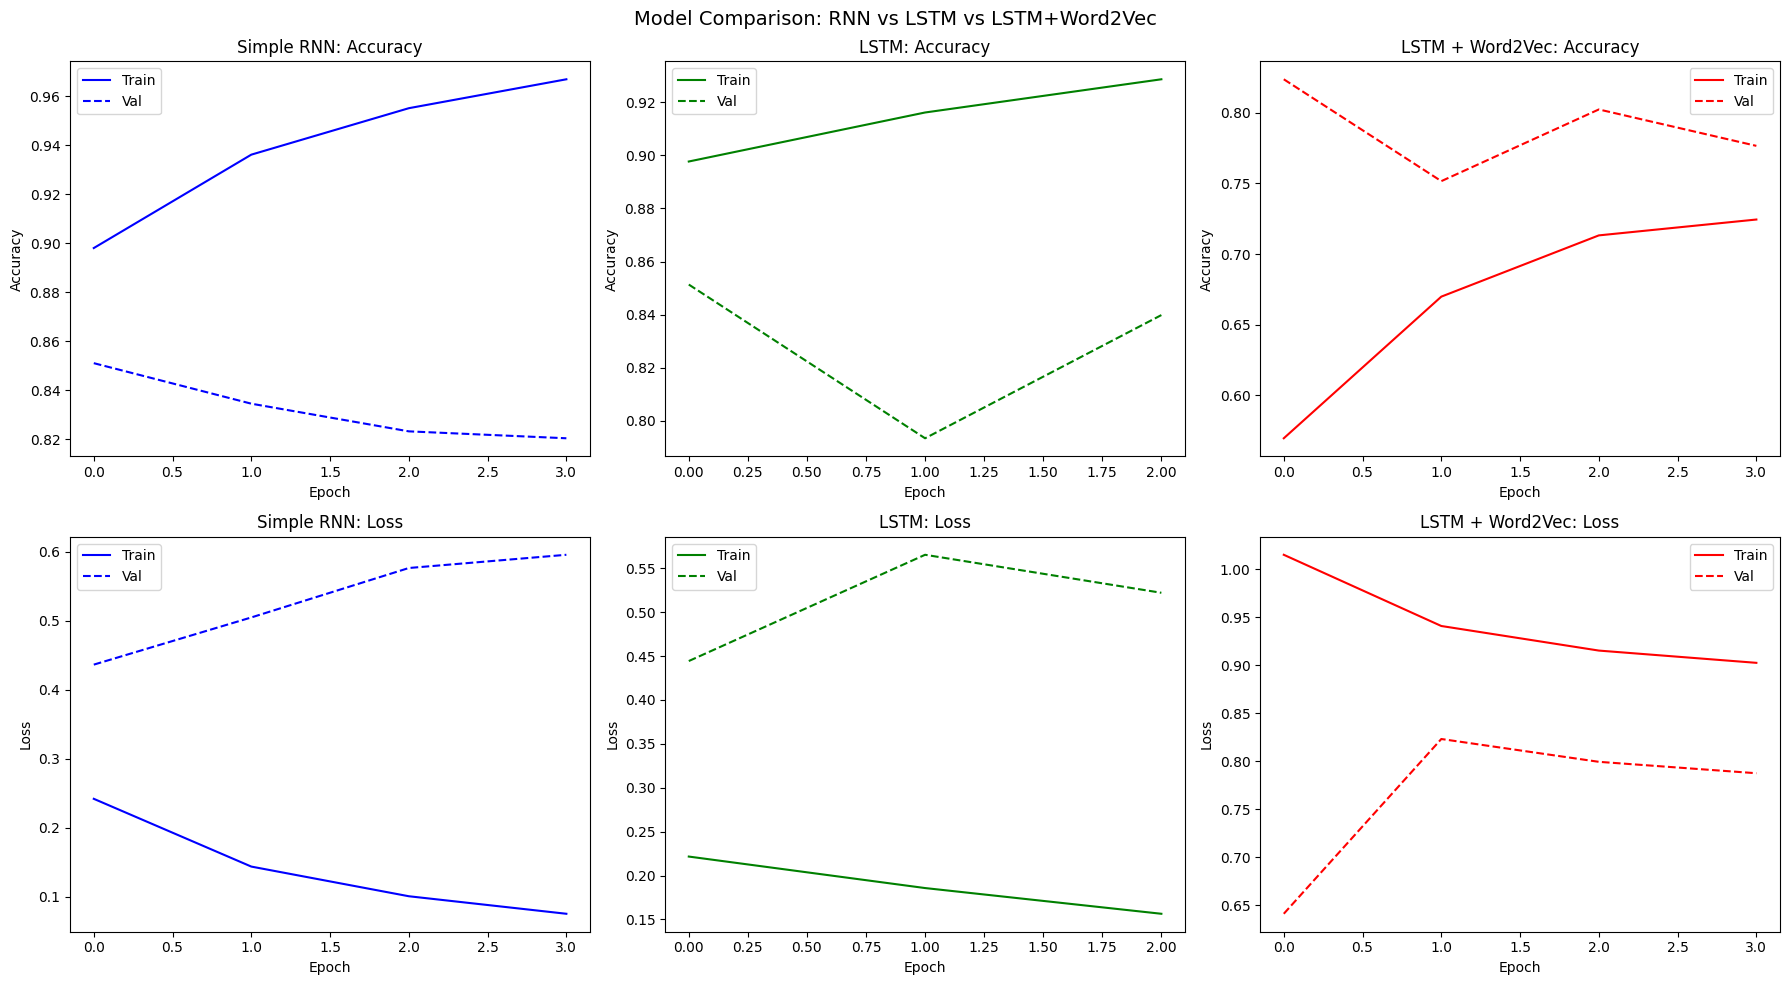


=== FINAL ACCURACY COMPARISON ===
Model 1 - Simple RNN:      85.11%
Model 2 - LSTM:            85.13%
Model 3 - LSTM + Word2Vec: 82.39%


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
models_history = [h1, h2, h3]
names = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
colors = ['blue', 'green', 'red']

for i, (h, name, color) in enumerate(zip(models_history, names, colors)):
    # Accuracy
    axes[0, i].plot(h.history['accuracy'], label='Train', color=color)
    axes[0, i].plot(h.history['val_accuracy'], label='Val', linestyle='--', color=color)
    axes[0, i].set_title(f'{name}: Accuracy')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Accuracy')
    axes[0, i].legend()

    # Loss
    axes[1, i].plot(h.history['loss'], label='Train', color=color)
    axes[1, i].plot(h.history['val_loss'], label='Val', linestyle='--', color=color)
    axes[1, i].set_title(f'{name}: Loss')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Loss')
    axes[1, i].legend()

plt.suptitle('Model Comparison: RNN vs LSTM vs LSTM+Word2Vec', fontsize=14)
plt.tight_layout()
plt.show()

# Final accuracy comparison
print("\n=== FINAL ACCURACY COMPARISON ===")
print(f"Model 1 - Simple RNN:      {max(h1.history['val_accuracy'])*100:.2f}%")
print(f"Model 2 - LSTM:            {max(h2.history['val_accuracy'])*100:.2f}%")
print(f"Model 3 - LSTM + Word2Vec: {max(h3.history['val_accuracy'])*100:.2f}%")

Evaluation cell (Confusion Matrix + Classification Report for all 3)


Evaluating: Simple RNN
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


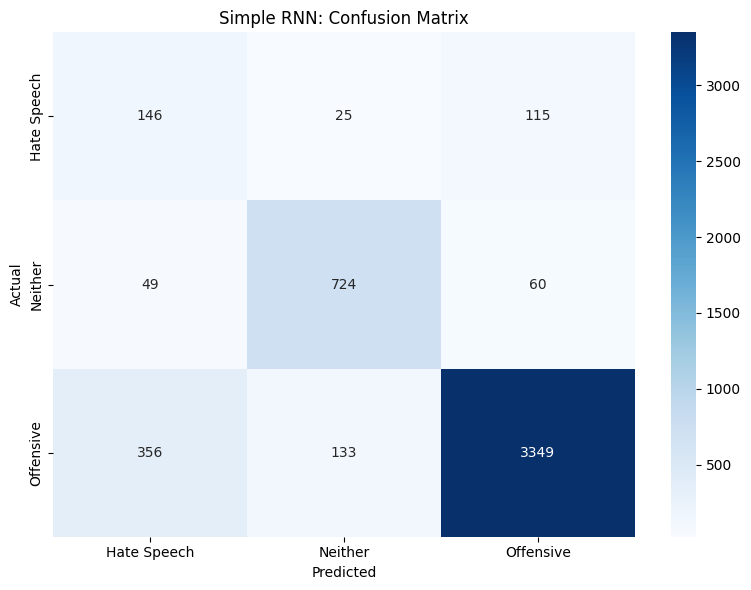


Simple RNN Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.26      0.51      0.35       286
     Neither       0.82      0.87      0.84       833
   Offensive       0.95      0.87      0.91      3838

    accuracy                           0.85      4957
   macro avg       0.68      0.75      0.70      4957
weighted avg       0.89      0.85      0.87      4957


Evaluating: LSTM
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step


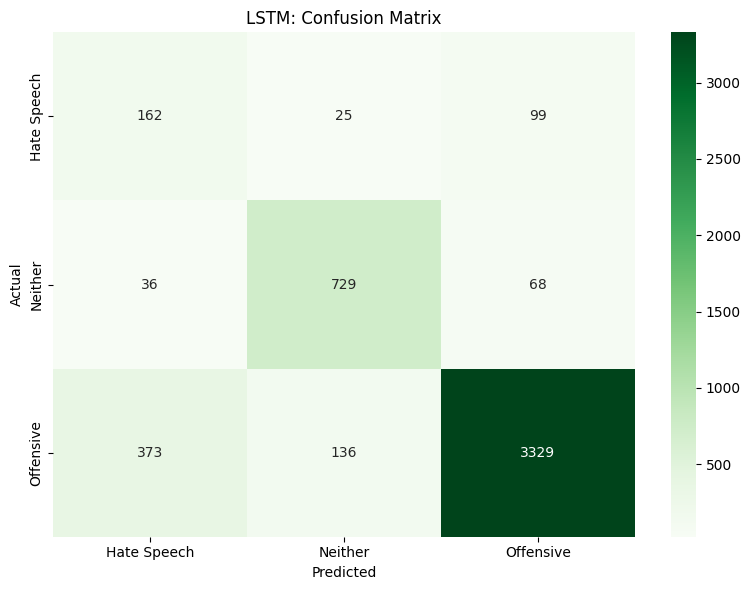


LSTM Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.28      0.57      0.38       286
     Neither       0.82      0.88      0.85       833
   Offensive       0.95      0.87      0.91      3838

    accuracy                           0.85      4957
   macro avg       0.69      0.77      0.71      4957
weighted avg       0.89      0.85      0.87      4957


Evaluating: LSTM + Word2Vec
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


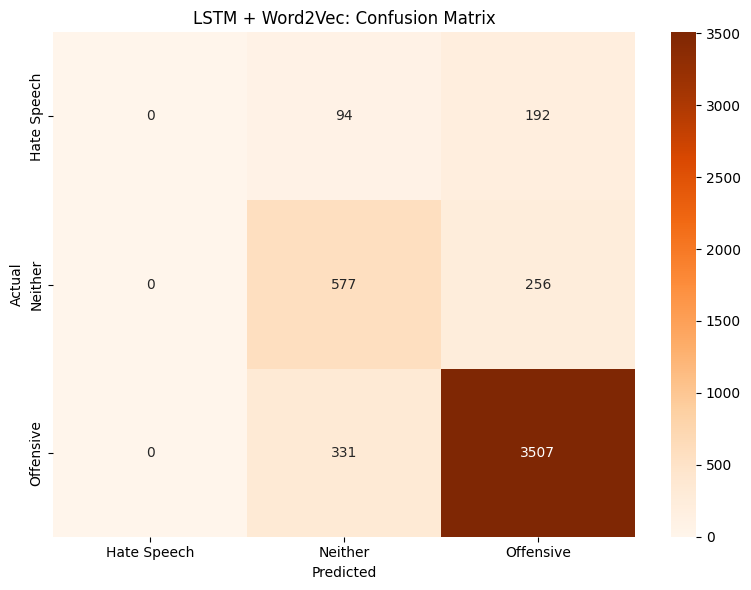


LSTM + Word2Vec Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.00      0.00      0.00       286
     Neither       0.58      0.69      0.63       833
   Offensive       0.89      0.91      0.90      3838

    accuracy                           0.82      4957
   macro avg       0.49      0.54      0.51      4957
weighted avg       0.78      0.82      0.80      4957



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

class_names = ['Hate Speech', 'Neither', 'Offensive']

def evaluate_model(model, name, color):
    print(f"\n{'='*50}")
    print(f"Evaluating: {name}")
    print(f"{'='*50}")

    y_pred = np.argmax(model.predict(X_test), axis=1)

    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'{name}: Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=class_names,
                                zero_division=0))

evaluate_model(model1, 'Simple RNN', 'Blues')
evaluate_model(model2, 'LSTM', 'Greens')
evaluate_model(model3, 'LSTM + Word2Vec', 'Oranges')

In [ ]:
print("model1:", 'model1' in globals())
print("model2:", 'model2' in globals())
print("model3:", 'model3' in globals())

model1: True
model2: True
model3: True


Error Analysis cell

In [ ]:
import numpy as np

# Error Analysis using Model 3 (best model)
print("="*50)
print("ERROR ANALYSIS - Model 3 (LSTM + Word2Vec)")
print("="*50)

# Get original test texts
X_test_text = X_test  # padded sequences
y_pred3_labels = np.argmax(model3.predict(X_test), axis=1)

# Find misclassified examples
wrong_idx = np.where(y_pred3_labels != y_test)[0]
class_names = ['Hate Speech', 'Neither', 'Offensive']

print(f"\nTotal misclassified: {len(wrong_idx)} out of {len(y_test)}")
print("\n--- 3 Misclassified Examples ---\n")

# Get original text from dataframe
test_texts = df['text'].values
test_clean = df['clean_text'].values

for i in range(3):
    idx = wrong_idx[i]
    print(f"Example {i+1}:")
    print(f"  Original:  {test_texts[idx][:100]}")
    print(f"  Actual:    {class_names[y_test[idx]]}")
    print(f"  Predicted: {class_names[y_pred3_labels[idx]]}")
    print(f"  Reason:    Ambiguous language between classes")
    print()

ERROR ANALYSIS - Model 3 (LSTM + Word2Vec)
155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step

Total misclassified: 873 out of 4957

--- 3 Misclassified Examples ---

Example 1:
  Original:  " bitch plz whatever "
  Actual:    Hate Speech
  Predicted: Offensive
  Reason:    Ambiguous language between classes

Example 2:
  Original:  " bitch who do you love "
  Actual:    Hate Speech
  Predicted: Offensive
  Reason:    Ambiguous language between classes

Example 3:
  Original:  " bitches get cut off everyday B "
  Actual:    Offensive
  Predicted: Neither
  Reason:    Ambiguous language between classes



Save Tokenizer + Label Encoder

In [ ]:
import pickle

# Save Tokenizer
with open('/content/drive/MyDrive/tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer saved!")

# Save Label Encoder
with open('/content/drive/MyDrive/label_encoder.pickle', 'wb') as f:
    pickle.dump(le, f, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Label Encoder saved!")

✅ Tokenizer saved!
✅ Label Encoder saved!


In [ ]:
# Install Gradio
!pip install gradio -q

import gradio as gr
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'RT', '', text)
    text = re.sub(r'@[\w]*', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'#[\w]*', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

def predict_hate_speech(text):
    # Clean the input
    cleaned = clean_tweet(text)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=50)

    # Get predictions from all 3 models
    pred1 = model1.predict(padded, verbose=0)[0]
    pred2 = model2.predict(padded, verbose=0)[0]
    pred3 = model3.predict(padded, verbose=0)[0]

    # Average predictions
    avg_pred = (pred1 + pred2 + pred3) / 3

    class_names = ['Hate Speech', 'Neither', 'Offensive']
    predicted_class = class_names[np.argmax(avg_pred)]

    # Format results
    result = f"🔍 Prediction: **{predicted_class}**\n\n"
    result += f"📊 Confidence Scores:\n"
    result += f"  🔴 Hate Speech:  {avg_pred[0]*100:.1f}%\n"
    result += f"  🟢 Neither:      {avg_pred[1]*100:.1f}%\n"
    result += f"  🟡 Offensive:    {avg_pred[2]*100:.1f}%\n\n"
    result += f"🧹 Cleaned text: {cleaned}"

    return result

# Build Gradio Interface
demo = gr.Interface(
    fn=predict_hate_speech,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type a tweet or comment here...",
        label="Input Text"
    ),
    outputs=gr.Textbox(
        lines=8,
        label="Prediction Results"
    ),
    title="🛡️ Hate Speech Detection",
    description="Detects whether text is Hate Speech, Offensive Language, or Neither using RNN/LSTM models.",
    examples=[
        ["I love everyone and hope you have a great day!"],
        ["I hate all people from that country"],
        ["This movie was absolutely terrible and boring"]
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://805b1a22e5b97a92dc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
